In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../dataset/housing.csv.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
df = df.dropna()

In [6]:
X = df.drop(
    ["median_house_value", "ocean_proximity"],
    axis=1
).values
y = df["median_house_value"].values

In [7]:
np.random.seed(42)

indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

In [8]:
split_index = int(0.8 * len(X))

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (16346, 8)
Test Shape: (4087, 8)


In [9]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

In [10]:
y_mean = y_train.mean()
y_std = y_train.std()

y_train = (y_train - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

In [11]:
n_samples = X_train.shape[0]
n_features = X_train.shape[1]

w = np.zeros(n_features)
b = 0

learning_rate = 0.001
epochs = 5000

losses = []

In [12]:

for epoch in range(epochs):

    # Prediction
    y_pred = X_train @ w + b

    # Gradients
    dw = (-2 / n_samples) * (X_train.T @ (y_train - y_pred))
    db = (-2 / n_samples) * np.sum(y_train - y_pred)

    # Update
    w -= learning_rate * dw
    b -= learning_rate * db

    # Loss
    loss = np.mean((y_train - y_pred) ** 2)

    losses.append(loss)

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch} | Loss = {loss:.6f}"
        )

Epoch 0 | Loss = 1.000000
Epoch 500 | Loss = 0.533270
Epoch 1000 | Loss = 0.454200
Epoch 1500 | Loss = 0.432061
Epoch 2000 | Loss = 0.420253
Epoch 2500 | Loss = 0.411448
Epoch 3000 | Loss = 0.404242
Epoch 3500 | Loss = 0.398212
Epoch 4000 | Loss = 0.393134
Epoch 4500 | Loss = 0.388845


In [13]:
y_pred_test = X_test @ w + b

mse = np.mean(
    (y_test - y_pred_test) ** 2
)

print("\nTest MSE:", mse)

ss_res = np.sum(
    (y_test - y_pred_test) ** 2
)

ss_tot = np.sum(
    (y_test - np.mean(y_test)) ** 2
)

r2 = 1 - (ss_res / ss_tot)

print("R2 Score:", r2)


Test MSE: 0.38602056968517706
R2 Score: 0.6109343111875708


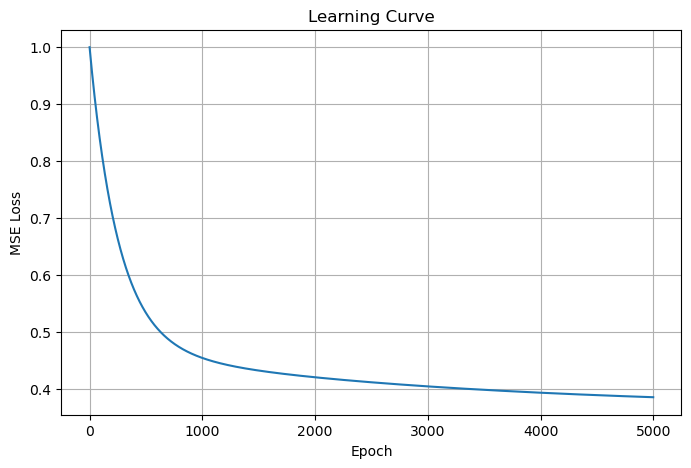

In [14]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curve")

plt.grid(True)

plt.show()

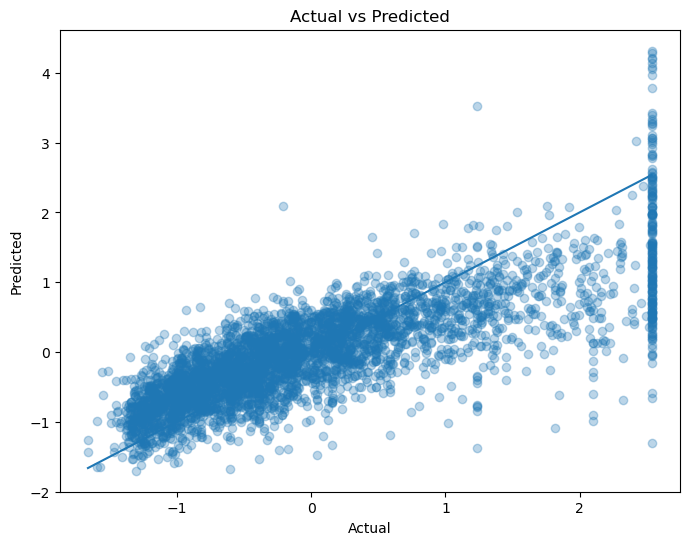

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()